In [5]:
import pandas as pd

df = pd.read_csv('../data/raw/cpih_annual_rate.csv')
df.head(10)


,Title,CPIH ANNUAL RATE 00: ALL ITEMS 2015=100
0,CDID,L55O
1,Source dataset ID,MM23
2,PreUnit,NaN
3,Unit,%
4,Release date,17-06-2026
5,Next release,22 July 2026
6,Important notes,NaN
7,1989,5.7
8,1990,8.0
9,1991,7.5


In [2]:
import os
print(os.getcwd())
print(os.listdir('../data/raw'))

c:\Users\kdzam\Documents\uk-cpi-inflation-forecasting\notebooks
['cpih_annual_rate.csv']


In [3]:
import pandas as pd

df = pd.read_csv('../data/raw/cpih_annual_rate.csv')
df.head(10)

,Title,CPIH ANNUAL RATE 00: ALL ITEMS 2015=100
0,CDID,L55O
1,Source dataset ID,MM23
2,PreUnit,NaN
3,Unit,%
4,Release date,17-06-2026
5,Next release,22 July 2026
6,Important notes,NaN
7,1989,5.7
8,1990,8.0
9,1991,7.5


In [4]:
df = pd.read_csv('../data/raw/cpih_annual_rate.csv.csv', skiprows=8, names=['period', 'value'])
print(df.shape)
df.head(15)
df.tail(15)


FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/cpih_annual_rate.csv.csv'

In [ ]:
import re

def is_monthly(period):
    return bool(re.match(r'^\d{4} (JAN|FEB|MAR|APR|MAY|JUN|JUL|AUG|SEP|OCT|NOV|DEC)$', str(period).strip()))

monthly_df = df[df['period'].apply(is_monthly)].copy()
print(monthly_df.shape)
monthly_df.head()
monthly_df['date'] = pd.to_datetime(monthly_df['period'], format='%Y %b')
monthly_df = monthly_df.sort_values('date').reset_index(drop=True)
monthly_df.head()

(449, 2)


,period,value,date
0,1989 JAN,5.7,1989-01-01
1,1989 FEB,5.8,1989-02-01
2,1989 MAR,5.9,1989-03-01
3,1989 APR,5.6,1989-04-01
4,1989 MAY,5.9,1989-05-01


Matplotlib is building the font cache; this may take a moment.


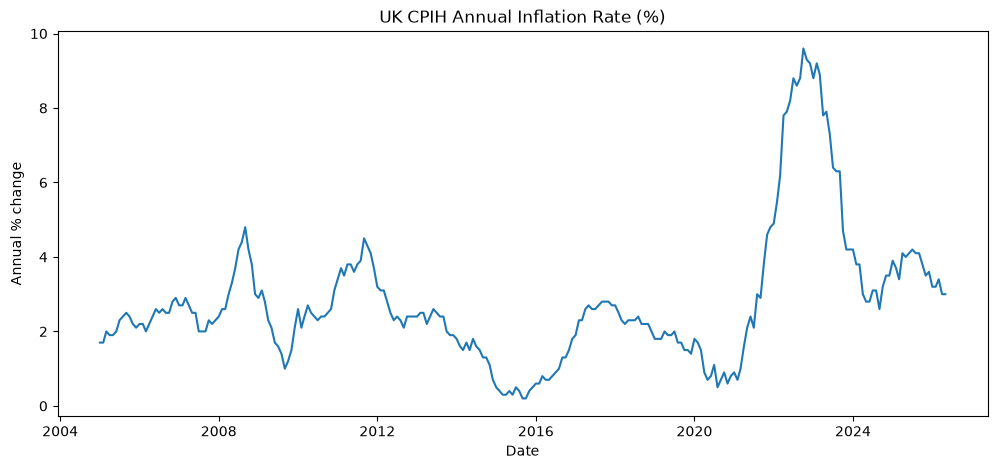

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_df['date'], monthly_df['value'])
plt.title('UK CPIH Annual Inflation Rate (%)')
plt.xlabel('Date')
plt.ylabel('Annual % change')
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_df['value'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])


ADF Statistic: -2.411773833795099
p-value: 0.13844086878189238


In [ ]:
monthly_df['value_diff'] = monthly_df['value'].diff()

result_diff = adfuller(monthly_df['value_diff'].dropna())
print('ADF Statistic:', result_diff[0])
print('p-value:', result_diff[1])

ADF Statistic: -5.28492553386692
p-value: 5.883392427029454e-06


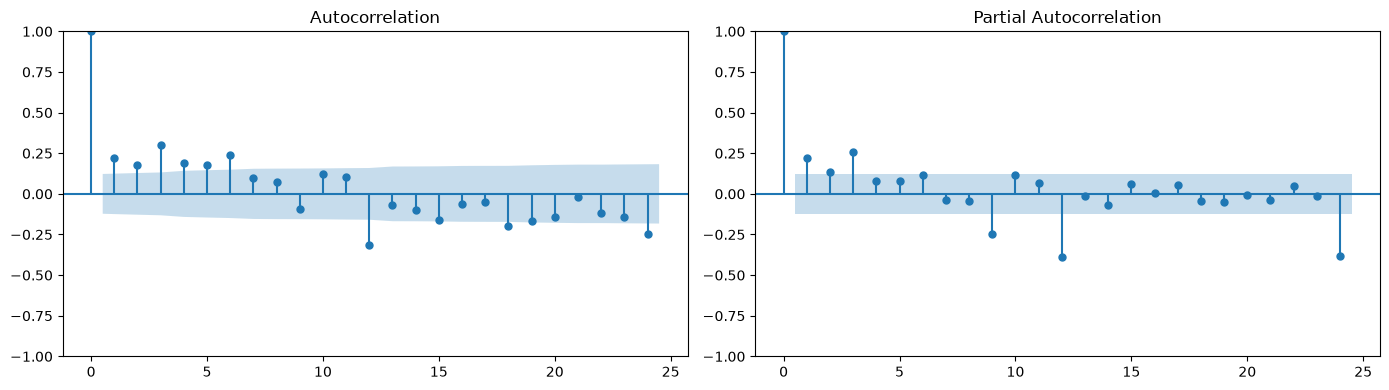

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
plot_acf(monthly_df['value_diff'].dropna(), lags=24, ax=axes[0])
plot_pacf(monthly_df['value_diff'].dropna(), lags=24, ax=axes[1])
plt.tight_layout()
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly_df['value'], order=(3,1,1))
model_fit = model.fit()
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  257
Model:                 ARIMA(3, 1, 1)   Log Likelihood                 -56.857
Date:                Fri, 17 Jul 2026   AIC                            123.714
Time:                        19:51:44   BIC                            141.440
Sample:                             0   HQIC                           130.843
                                - 257                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5685      0.142      4.003      0.000       0.290       0.847
ar.L2          0.0074      0.071      0.104      0.917      -0.131       0.146
ar.L3          0.1957      0.053      3.714      0.0

In [ ]:
model_simple = ARIMA(monthly_df['value'], order=(1,1,1))
model_simple_fit = model_simple.fit()
print(model_simple_fit.summary())

c:\Users\kdzam\Documents\uk-cpi-inflation-forecasting\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


                               SARIMAX Results                                
Dep. Variable:                  value   No. Observations:                  257
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 -60.647
Date:                Fri, 17 Jul 2026   AIC                            127.294
Time:                        19:52:31   BIC                            137.929
Sample:                             0   HQIC                           131.571
                                - 257                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.8681      0.053     16.495      0.000       0.765       0.971
ma.L1         -0.6933      0.080     -8.689      0.000      -0.850      -0.537
sigma2         0.0940      0.006     15.832      0.0

In [ ]:
train_size = int(len(monthly_df) * 0.8)
train = monthly_df['value'][:train_size]
test = monthly_df['value'][train_size:]

print(f"Train: {len(train)} months, Test: {len(test)} months")
print(f"Test period starts: {monthly_df['date'].iloc[train_size]}")

Train: 205 months, Test: 52 months
Test period starts: 2022-02-01 00:00:00


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Naive benchmark: just repeat the last known value
naive_forecast = [train.iloc[-1]] * len(test)

# Fit ARIMA on training data only, forecast the test period
model_eval = ARIMA(train, order=(1,1,1))
model_eval_fit = model_eval.fit()
arima_forecast = model_eval_fit.forecast(steps=len(test))

# Compare
naive_rmse = np.sqrt(mean_squared_error(test, naive_forecast))
arima_rmse = np.sqrt(mean_squared_error(test, arima_forecast))
naive_mae = mean_absolute_error(test, naive_forecast)
arima_mae = mean_absolute_error(test, arima_forecast)

print(f"Naive  - RMSE: {naive_rmse:.3f}, MAE: {naive_mae:.3f}")
print(f"ARIMA  - RMSE: {arima_rmse:.3f}, MAE: {arima_mae:.3f}")

Naive  - RMSE: 2.308, MAE: 1.977
ARIMA  - RMSE: 2.322, MAE: 2.149


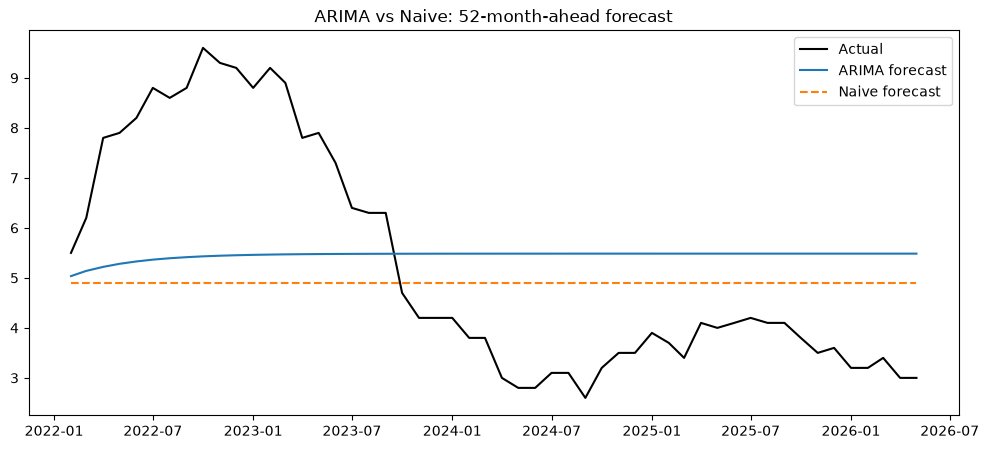

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(monthly_df['date'][train_size:], test.values, label='Actual', color='black')
plt.plot(monthly_df['date'][train_size:], arima_forecast, label='ARIMA forecast', color='tab:blue')
plt.plot(monthly_df['date'][train_size:], naive_forecast, label='Naive forecast', color='tab:orange', linestyle='--')
plt.title('ARIMA vs Naive: 52-month-ahead forecast')
plt.legend()
plt.savefig('../results/figures/arima_vs_naive_52month.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
rolling_actuals = []
rolling_arima = []
rolling_naive = []

history = list(train)

for t in range(len(test)):
    model_t = ARIMA(history, order=(1,1,1))
    model_t_fit = model_t.fit()
    forecast_t = model_t_fit.forecast(steps=1)[0]
    
    rolling_arima.append(forecast_t)
    rolling_naive.append(history[-1])
    rolling_actuals.append(test.iloc[t])
    
    history.append(test.iloc[t])

print("Done")

c:\Users\kdzam\Documents\uk-cpi-inflation-forecasting\venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\kdzam\Documents\uk-cpi-inflation-forecasting\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'


Done


In [ ]:
rolling_arima_rmse = np.sqrt(mean_squared_error(rolling_actuals, rolling_arima))
rolling_naive_rmse = np.sqrt(mean_squared_error(rolling_actuals, rolling_naive))
rolling_arima_mae = mean_absolute_error(rolling_actuals, rolling_arima)
rolling_naive_mae = mean_absolute_error(rolling_actuals, rolling_naive)

print(f"Rolling Naive  - RMSE: {rolling_naive_rmse:.3f}, MAE: {rolling_naive_mae:.3f}")
print(f"Rolling ARIMA  - RMSE: {rolling_arima_rmse:.3f}, MAE: {rolling_arima_mae:.3f}")

Rolling Naive  - RMSE: 0.506, MAE: 0.352
Rolling ARIMA  - RMSE: 0.475, MAE: 0.369


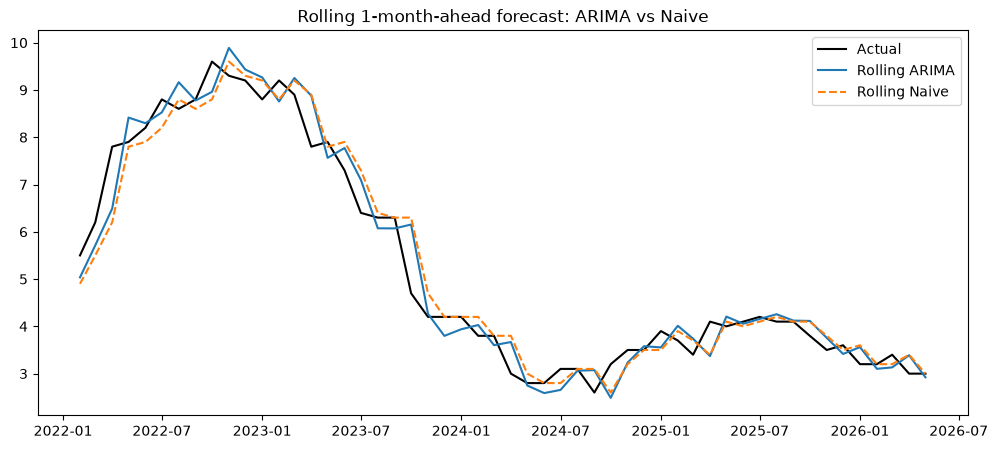

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(monthly_df['date'][train_size:], rolling_actuals, label='Actual', color='black')
plt.plot(monthly_df['date'][train_size:], rolling_arima, label='Rolling ARIMA', color='tab:blue')
plt.plot(monthly_df['date'][train_size:], rolling_naive, label='Rolling Naive', color='tab:orange', linestyle='--')
plt.title('Rolling 1-month-ahead forecast: ARIMA vs Naive')
plt.legend()
plt.savefig('../results/figures/rolling_forecast_comparison.png', dpi=150, bbox_inches='tight')
plt.show()